Dataset từ Hậu
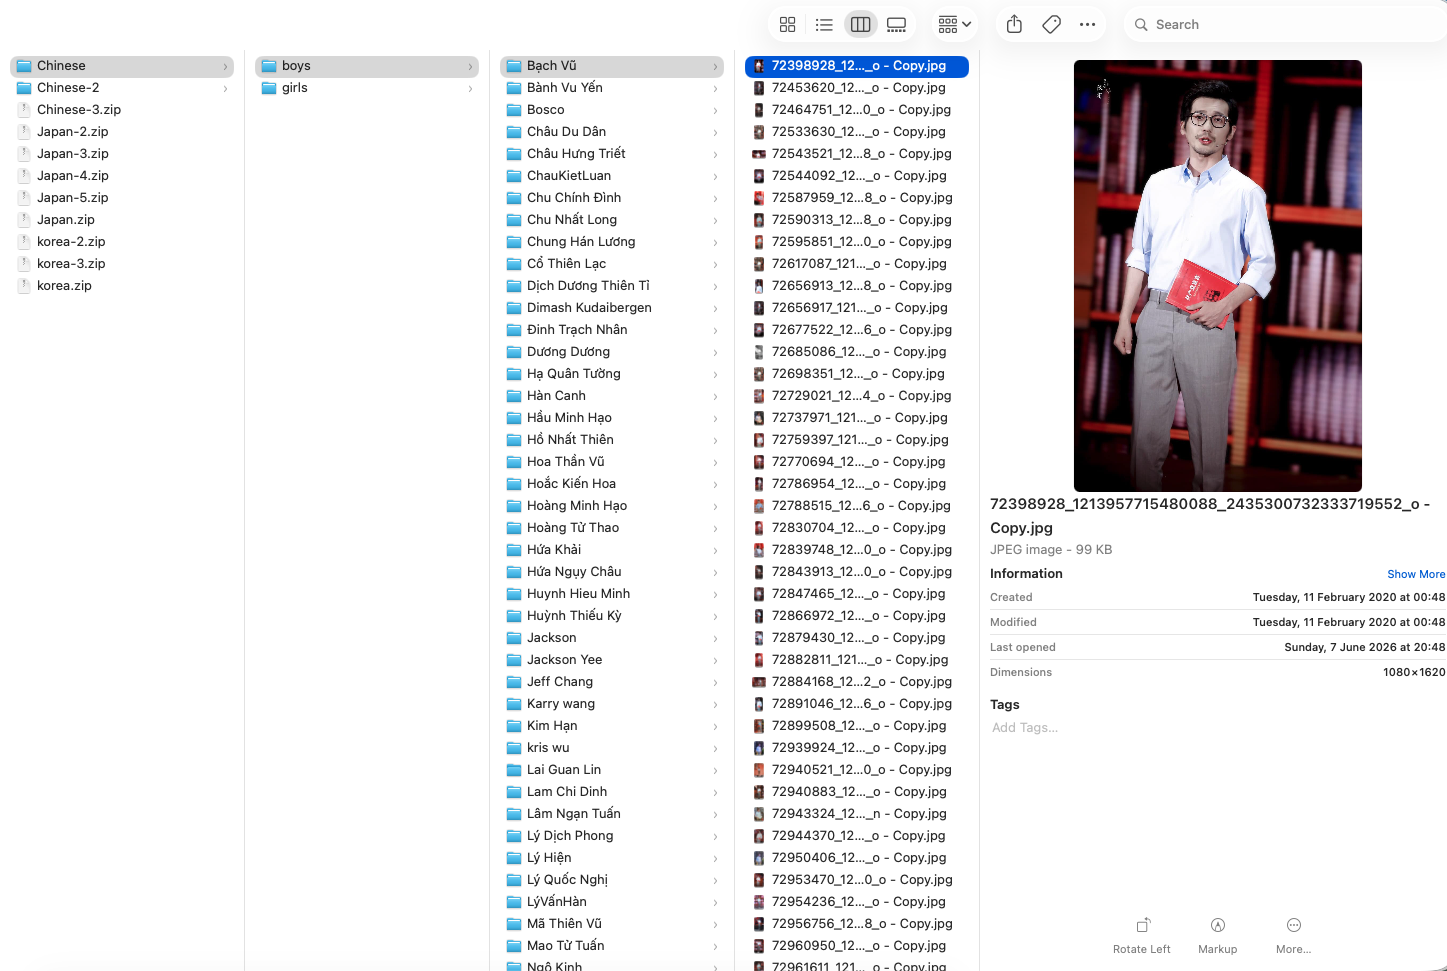

Dùng deepface để nhận dạng khuôn mặt sau đó  cắt với tỷ lệ (128 x 128) và bộ (64 x 64). từ bộ (128 x 128) downsample xuống tỷ lệ (24 x 24) - dùng để enhance.

CodeFormer
↓
GFPGAN
↓
RealESRGAN

Gốc 64 x 64

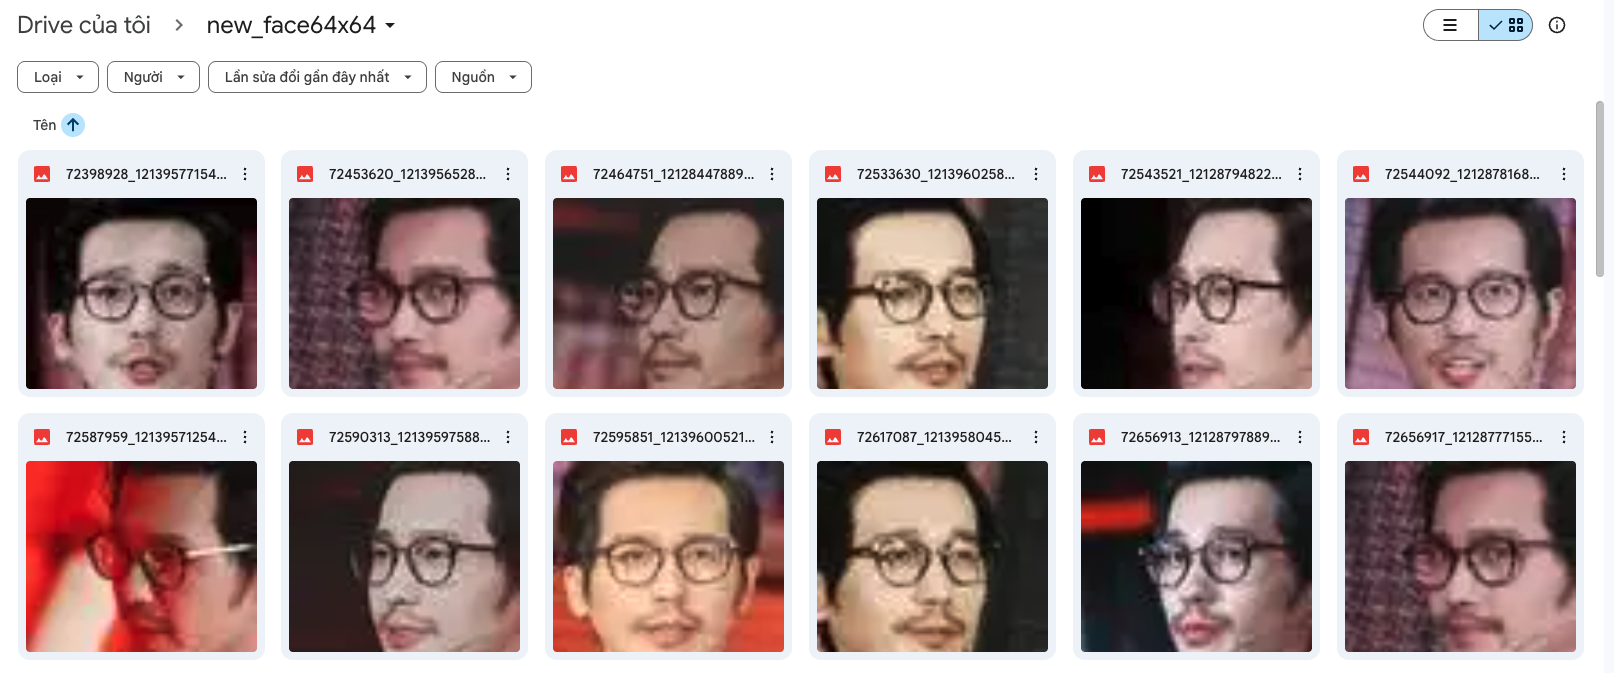

CodeFormer 64 x 64
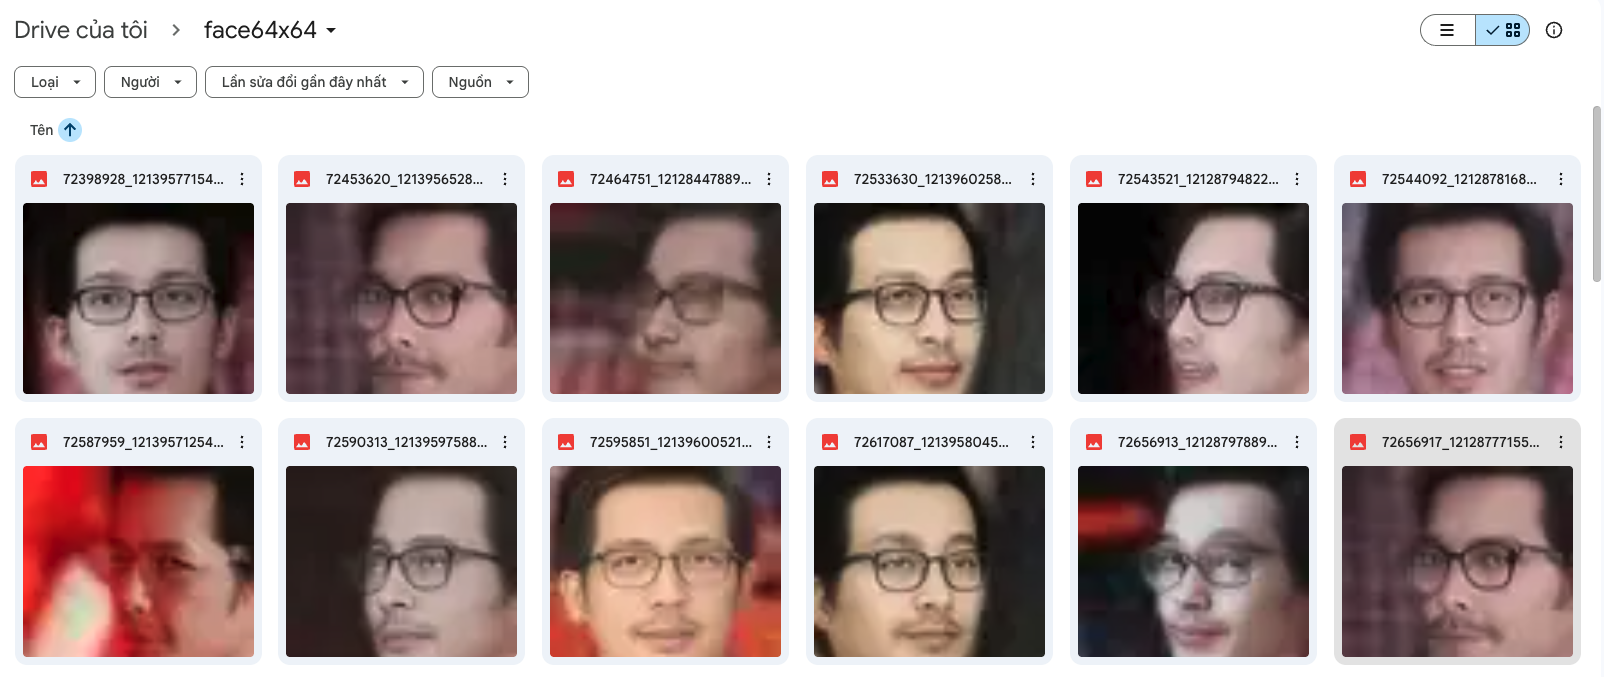

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

CODEFORMER_DIR = "/content/drive/MyDrive/CodeFormer"

if not os.path.exists(CODEFORMER_DIR):
    os.system(f"git clone https://github.com/sczhou/CodeFormer.git {CODEFORMER_DIR}")
else:
    print("CodeFormer already exists at", CODEFORMER_DIR)

os.system(f"pip install -r {CODEFORMER_DIR}/requirements.txt")

# Download required model weights
os.chdir(CODEFORMER_DIR)
os.system("python basicsr/setup.py develop")
os.system("python scripts/download_pretrained_models.py facelib")
os.system("python scripts/download_pretrained_models.py CodeFormer")

print("Setup complete. CodeFormer is at:", CODEFORMER_DIR)

24 x 24

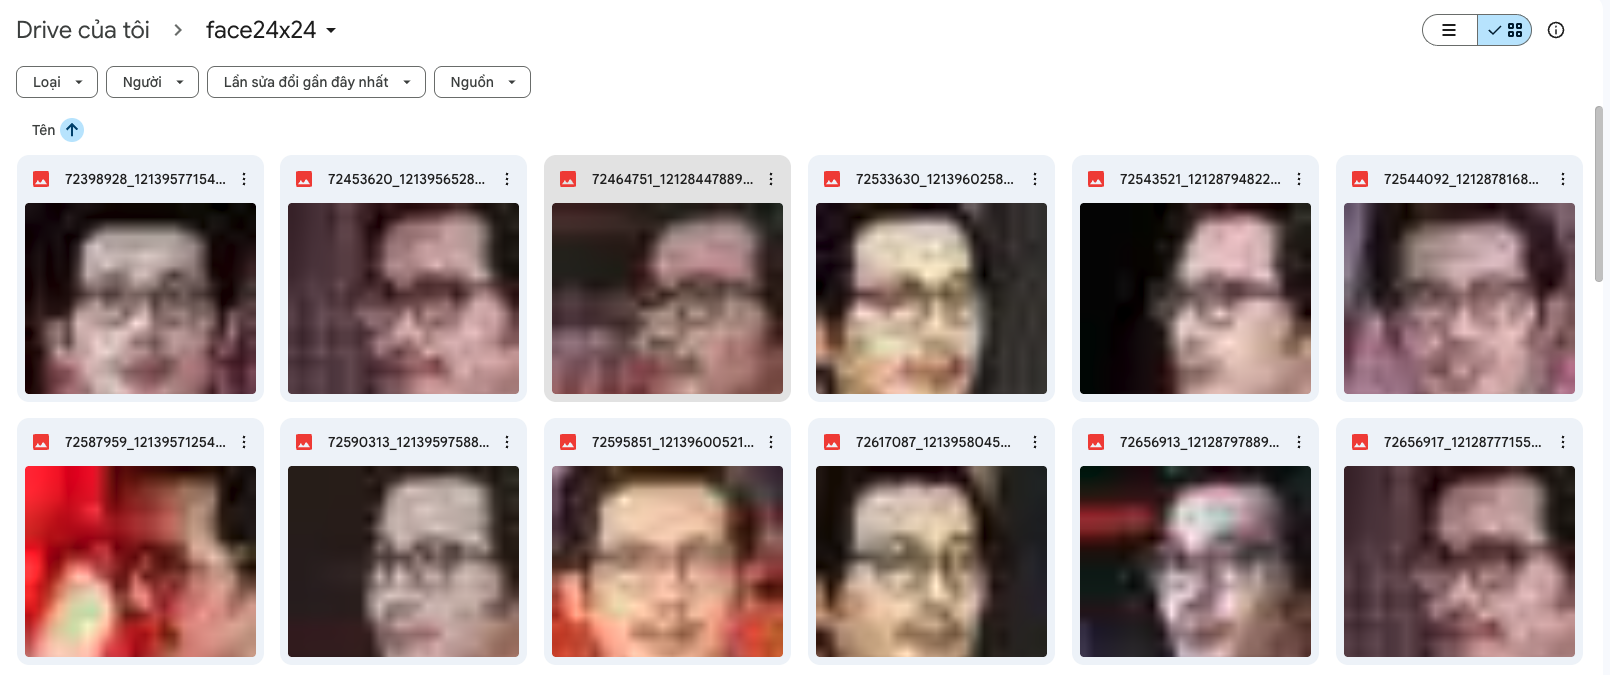

lasted version

In [ ]:
from google.colab import drive
import os
import glob
import shutil
import subprocess
from PIL import Image

drive.mount('/content/drive')

INPUT_DIR = "/content/drive/MyDrive/face24x24"
OUTPUT_DIR = "/content/drive/MyDrive/face64x64"

CODEFORMER_DIR = "/content/drive/MyDrive/CodeFormer"
CODEFORMER_W = 0.4

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lấy toàn bộ ảnh
images = []

for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
    images.extend(
        glob.glob(
            os.path.join(INPUT_DIR, "**", ext),
            recursive=True
        )
    )

images = sorted(images)

print(f"Found {len(images)} images")

# Path kết quả cố định, đúng theo cấu trúc thực tế đã xác nhận
RESULT_DIR = os.path.join(
    CODEFORMER_DIR, "results", f"test_img_{CODEFORMER_W}", "final_results"
)

success = 0
failed = 0
failed_list = []

for idx, img_path in enumerate(images, start=1):

    filename = os.path.basename(img_path)
    name_no_ext = os.path.splitext(filename)[0]

    print(f"\n[{idx}/{len(images)}] {filename}")

    try:
        # Xóa kết quả cũ để tránh lẫn ảnh giữa các lần chạy
        shutil.rmtree(
            os.path.join(CODEFORMER_DIR, "results"),
            ignore_errors=True
        )

        cmd = [
            "python",
            "inference_codeformer.py",
            "--input_path",
            img_path,
            "--face_upsample",
            "-w",
            str(CODEFORMER_W)
        ]

        result = subprocess.run(
            cmd,
            cwd=CODEFORMER_DIR,
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            print("  CodeFormer failed (return code != 0)")
            print(result.stderr[-1000:])
            failed += 1
            failed_list.append(img_path)
            continue

        # final_results lưu file theo tên gốc + đuôi .png (đã xác nhận từ thực tế)
        expected_output = os.path.join(RESULT_DIR, f"{name_no_ext}.png")

        if not os.path.exists(expected_output):
            # fallback: nếu tên không khớp 100%, quét toàn bộ final_results
            outputs = glob.glob(os.path.join(RESULT_DIR, "*"))
            if not outputs:
                print("  No output image generated")
                print("  STDOUT:", result.stdout[-500:])
                failed += 1
                failed_list.append(img_path)
                continue
            restored = max(outputs, key=os.path.getmtime)
        else:
            restored = expected_output

        img = Image.open(restored).convert("RGB")

        # Upscale rồi resize về 64x64
        img = img.resize((256, 256), Image.Resampling.LANCZOS)
        img = img.resize((64, 64), Image.Resampling.LANCZOS)

        save_path = os.path.join(OUTPUT_DIR, filename)
        img.save(save_path, quality=100)

        print("  Saved:", save_path)
        success += 1

    except Exception as e:
        print("  ERROR:", str(e))
        failed += 1
        failed_list.append(img_path)

print("\n====================")
print("Completed")
print("Success:", success)
print("Failed :", failed)
print("Output :", OUTPUT_DIR)

if failed_list:
    print("\nDanh sách ảnh lỗi:")
    for f in failed_list:
        print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 244 images

[1/244] 72398928_1213957715480088_2435300732333719552_o - Copy_face00.jpg
  Saved: /content/drive/MyDrive/face64x64/72398928_1213957715480088_2435300732333719552_o - Copy_face00.jpg

[2/244] 72453620_1213956528813540_2832795750805536768_o - Copy_face00.jpg
  Saved: /content/drive/MyDrive/face64x64/72453620_1213956528813540_2832795750805536768_o - Copy_face00.jpg

[3/244] 72464751_1212844788924714_3564593397052211200_o - Copy_face00.jpg
  Saved: /content/drive/MyDrive/face64x64/72464751_1212844788924714_3564593397052211200_o - Copy_face00.jpg

[4/244] 72533630_1213960258813167_239033346842165248_o - Copy_face00.jpg
  Saved: /content/drive/MyDrive/face64x64/72533630_1213960258813167_239033346842165248_o - Copy_face00.jpg

[5/244] 72543521_1212879482254578_8763209670258065408_o - Copy_face00.jpg
  Saved: /content/drive/MyDrive/face64x64/7254352

# so sánh

new_face64x64 là ground truth, face64x64 là kết quả CodeFormer cần đánh giá. Dùng 3 nhóm metric phù hợp với 3 hướng bạn chọn, viết và test trực tiếp trong sandbox này trước khi đưa code cho bạn, để đảm bảo chạy được trên Colab.

Nhóm 1 — Pixel-level similarity: PSNR và SSIM (dùng scikit-image, không cần GPU, đo độ giống pixel-by-pixel và cấu trúc ảnh).

Nhóm 2 — Face embedding similarity: dùng face_recognition hoặc DeepFace để trích embedding khuôn mặt rồi tính cosine similarity — đo xem CodeFormer có giữ đúng danh tính khuôn mặt không, quan trọng hơn PSNR/SSIM với ảnh khuôn mặt.

Nhóm 3 — No-reference quality (không cần ảnh gốc): đo độ sắc nét bằng biến thiên Laplacian (blur detection) — xem ảnh CodeFormer có "nét" hơn ảnh gốc 24x64 hay không, độc lập với việc so khớp pixel.